## Principal Component Analysis 1

This py-notebook will cover PCA (simple case), using the highly useful course provided by IIT Madras (Thank you!) :

 https://bsc-iitm.github.io/MLT_notes/pages/Not01.html

### Algorithm steps: 

Steps involved in PCA <br>
Step 1: Center the dataset

Step 2: Calculate the covariance matrix of the centered data

Step 3: Compute the eigenvectors and eigenvalues

Step 4: Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to the highest eigenvalues

Step 5: Transform the original data by multiplying it with the selected eigenvectors(PCs) to obtain a lower-dimensional representation.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

#### Creating the sample dataset

In [2]:
## Creating the sample dataset X (d * n)
X = np.array([(4,1),(5,4),(6,3),(7,4),(2,-1),(-1,-2),(0,-3),(-1,-4)]).T
X


array([[ 4,  5,  6,  7,  2, -1,  0, -1],
       [ 1,  4,  3,  4, -1, -2, -3, -4]])

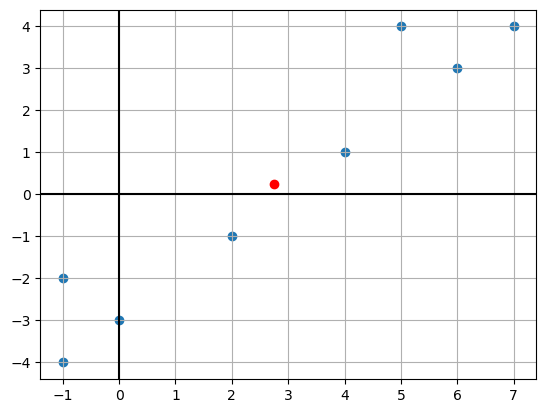

In [3]:
# Have a look at the data set 
plt.scatter(X[0, :], X[1 , :])
plt.axhline(0,color="k") # the x axis
plt.axvline(0,color="k") # the y axis 


# calculate the mean of the dataset 
X_mean = X.mean(axis=1)


# plot the mean point on the grid 
plt.scatter(X_mean[0], X_mean[1], color="r")
plt.grid()
plt.show()

In [10]:
# function to center the data set 

def center(X): 
    return X - X.mean(axis=1).reshape(2, 1)

d, n = X.shape 
X_centered = center(X)

In [11]:
print("X = ", X)
mean_  = X.mean(axis=1).reshape(2, 1)
print("mean = ", mean_)
print("X_Centered = ", X_centered)

X =  [[ 4  5  6  7  2 -1  0 -1]
 [ 1  4  3  4 -1 -2 -3 -4]]
mean =  [[2.75]
 [0.25]]
X_Centered =  [[ 1.25  2.25  3.25  4.25 -0.75 -3.75 -2.75 -3.75]
 [ 0.75  3.75  2.75  3.75 -1.25 -2.25 -3.25 -4.25]]


#### Lets have a look at the centered dataset

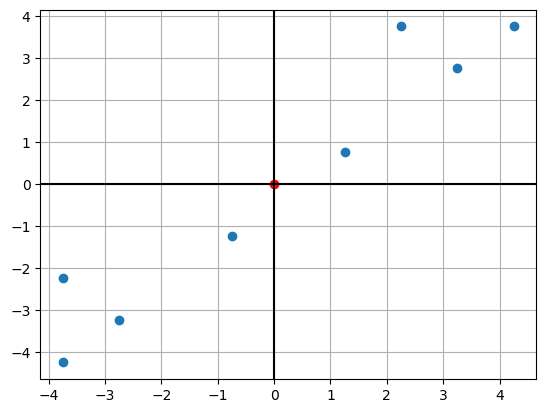

In [17]:
# Have a look at the data set 
plt.scatter(X_centered[0, :], X_centered[1 , :])
plt.axhline(0,color="k") # the x axis
plt.axvline(0,color="k") # the y axis 

centered_mean = X_centered.mean(axis=1)

# plot the mean point on the grid 
plt.scatter(centered_mean[0], centered_mean[1], color="r")
plt.grid()
plt.show()

### compare both plots 

Text(0.5, 1.0, 'after labelling')

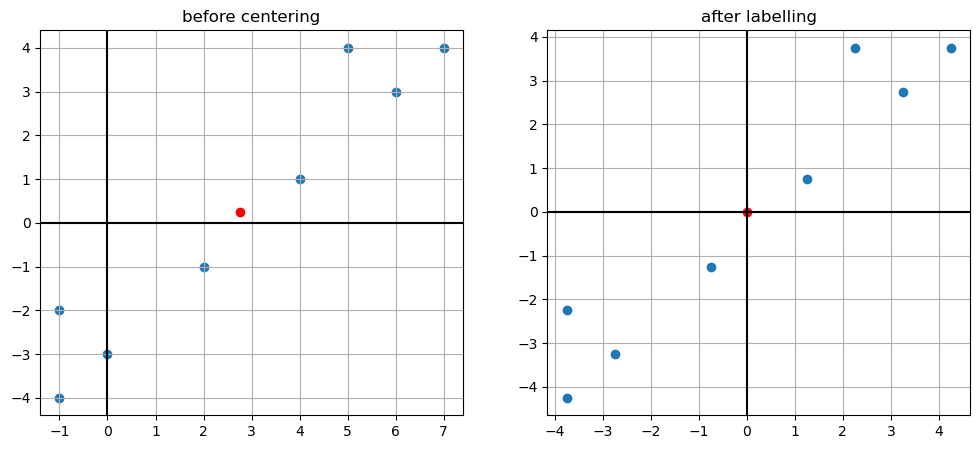

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1 , 2 , 1)
plt.scatter(X[0, :], X[1 , :])
plt.axhline(0, color="k")
plt.axvline(0, color="k")

x_mean = X.mean(axis=1)

plt.scatter(x_mean[0], x_mean[1], color="r")
plt.grid()
plt.title("before centering")


plt.subplot(1 , 2 , 2)
plt.scatter(X_centered[0 , :], X_centered[1 , :])
plt.axhline(0, color="k")
plt.axvline(0, color="k")

x_center_mean = X_centered.mean(axis=1)

plt.scatter(x_center_mean[0], x_center_mean[1], color="r")
plt.grid()
plt.title("after labelling")

### Calculate Covariance matrix of the centered dataset

Covariance matrix is given by : 

$C =   1/n \Sigma {x_{i}x_{i}^T}$

$C = 1/n {X}{X}^T$

In [20]:
# creating the covariance matrix 

def covr(X): 
    return (X @ X.T)/X.shape[1]

C = covr(X_centered)
C

array([[8.9375, 8.5625],
       [8.5625, 8.9375]])

In [21]:
# Compute eigenvectors and eigenvalues 

def compute_pc(C): 
    eigval, eigvec = np.linalg.eigh(C)
    w1 , w2 = eigvec[: , -1], eigvec[: , -2]
    return w1, w2 

w1, w2 = compute_pc(C)
w1 = w1.reshape((w1.shape[0] ,1 ))
w2 = w2.reshape((w2.shape[0] ,1 ))

w1, w2

    

(array([[0.70710678],
        [0.70710678]]),
 array([[-0.70710678],
        [ 0.70710678]]))

the scalar projection of the data set ${X_{centered}}$ on the $k_{th}$ principal component is given as : $X_{centered}^T . w_{k} $

In [32]:
print("full reconstruction = ", w1 @ (X_centered.T @ w1).reshape(1, n) + w2 @ (X_centered.T @ w2).reshape(1, n))
print("centered dataset = " , X_centered)

full reconstruction =  [[ 1.25  2.25  3.25  4.25 -0.75 -3.75 -2.75 -3.75]
 [ 0.75  3.75  2.75  3.75 -1.25 -2.25 -3.25 -4.25]]
centered dataset =  [[ 1.25  2.25  3.25  4.25 -0.75 -3.75 -2.75 -3.75]
 [ 0.75  3.75  2.75  3.75 -1.25 -2.25 -3.25 -4.25]]


In [40]:
p1 = w1 @ (X_centered.T @ w1).reshape(1 , n)

print("Data set along 1st PC = " , p1)
print("reconstruction error")

rec_err = np.square(np.linalg.norm(X_centered[: ,]-p1[:, ] , axis=0))
print(rec_err)

Data set along 1st PC =  [[ 1.  3.  3.  4. -1. -3. -3. -4.]
 [ 1.  3.  3.  4. -1. -3. -3. -4.]]
reconstruction error
[0.125 1.125 0.125 0.125 0.125 1.125 0.125 0.125]


In [41]:
#Total reconstruction error when considering first principal component

print("The reconstruction error along the first principal component is "+str(np.round((rec_err).mean(),4)))

The reconstruction error along the first principal component is 0.375


One can verify, that along any other axis, the recontruction error would be subtstantially higher than this